**Import libraries**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt

**Load file as dataframe**

In [2]:
folder_path = "../data/emg_data_original"
file_names = [f"grip_{i}.txt" for i in range(1, 13)]  # grip_1.txt to grip_12.txt

# Initialize an empty list to store DataFrames
all_data = []

# Loop through each file and load its data
for grip_num, file_name in enumerate(file_names, start=1):
    file_path = os.path.join(folder_path, file_name)
    
    data = []
    gesture_repetition = 0

    # Read the file line by line
    with open(file_path, "r") as file:
        for line in file:
            line = line.strip()

            # If "#" appears, increase repetition count
            if line.startswith("#"):
                gesture_repetition += 1
                continue

            # Split by ";" and convert to float
            values = line.split(";")
            values = [float(v) for v in values if v]
            
            # Append to list with repetition index and grip pattern label
            if len(values) >= 6:
                data.append([gesture_repetition, grip_num, values[1]])

    # Convert to DataFrame
    columns = ["gesture_repetition", "grip_pattern", "ch2_raw"]
    df = pd.DataFrame(data, columns=columns)
    df.dropna(inplace=True)  # Remove NaNs if any

    # Append to master list
    all_data.append(df)

# Merge all DataFrames into one
merged_df = pd.concat(all_data, ignore_index=True)

# Save merged dataset to CSV
merged_df.to_csv("../data/emg_data_processed/merged_emg_data_ch2.csv", index=False)

print("Merged dataset saved as 'merged_emg_data_ch2.csv'.")
print(merged_df.head())  # Show first few rows

Merged dataset saved as 'merged_emg_data_ch2.csv'.
   gesture_repetition  grip_pattern  ch2_raw
0                   1             1  2.87193
1                   1             1  2.87384
2                   1             1  2.87804
3                   1             1  2.87369
4                   1             1  2.87132


**Sliding windows**

In [3]:
df = pd.read_csv("../data/emg_data_processed/merged_emg_data_ch2.csv")

WINDOW_SIZE = 200  # 200 time steps per window
STEP_SIZE = 50  # Overlapping step size

windowed_data = []
windowed_labels = []

# Loop through each gesture repetition
for repetition in df["gesture_repetition"].unique():
    subset = df[df["gesture_repetition"] == repetition]  # Filter one repetition

    # Apply sliding window segmentation
    for start in range(0, len(subset) - WINDOW_SIZE, STEP_SIZE):
        window = subset.iloc[start : start + WINDOW_SIZE]["ch2_raw"]
        windowed_data.append(window.values.flatten())  # Flatten to 1D
        windowed_labels.append(subset["grip_pattern"].iloc[start])  # Use first row's label

# Convert to DataFrame
num_features = WINDOW_SIZE # 1 EMG channel per time step
columns = [f"feature_{i}" for i in range(num_features)] + ["grip_pattern"]
windowed_df = pd.DataFrame(np.column_stack((windowed_data, windowed_labels)), columns=columns)

# Save processed dataset
windowed_df.to_csv("../data/emg_data_processed/sliding_windows_emg_ch2.csv", index=False)

print(windowed_df.head())  # Check the first few rows

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0    2.87193    2.87384    2.87804    2.87369    2.87132    2.87315   
1    2.87399    2.87491    2.87010    2.87094    2.87193    2.87201   
2    2.87262    2.87262    2.86987    2.87369    2.87094    2.87163   
3    2.87064    2.87415    2.87827    2.87155    2.87231    2.87514   
4    2.87788    2.87247    2.87872    2.87193    2.87163    2.87376   

   feature_6  feature_7  feature_8  feature_9  ...  feature_191  feature_192  \
0    2.87399    2.87231    2.87308    2.87056  ...      2.87285      2.87033   
1    2.87315    2.87308    2.87544    2.87148  ...      2.87033      2.87827   
2    2.87376    2.87064    2.87148    2.87697  ...      2.87224      2.87437   
3    2.87140    2.87132    2.86835    2.87102  ...      2.87132      2.87506   
4    2.87399    2.87399    2.87201    2.87262  ...      2.87125      2.87018   

   feature_193  feature_194  feature_195  feature_196  feature_197  \
0      2.87201      2.

**Load and preprocess data for CNN**

In [4]:
df = pd.read_csv("../data/emg_data_processed/sliding_windows_emg_ch2.csv")

# Separate features and labels
X = df.drop(columns=["grip_pattern"]).values
y = df["grip_pattern"].values

# Split data: 70% train, 10% tune, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_tune, y_train, y_tune = train_test_split(X_temp, y_temp, test_size=0.125, stratify=y_temp)

# Normalize after splitting to prevent data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN: (samples, time_steps, channels)
time_steps = 200  # Each window has 200 time steps
num_channels = 1  # 1 EMG signal per time step
X_train = X_train.reshape((-1, time_steps, num_channels))
X_tune = X_tune.reshape((-1, time_steps, num_channels))
X_test = X_test.reshape((-1, time_steps, num_channels))

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (67924, 200, 1)
Testing Data Shape: (19407, 200, 1)


**One hot encoding for gesture labels**

In [5]:
y_train = np.array(y_train) - 1
y_test = np.array(y_test) - 1

# 12 grip patterns
num_classes = len(np.unique(y_train))

# Integer to one-hot encoding
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(y_train[:5])  # Print first 5 labels in one-hot format

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


**Build CNN**

In [6]:
# Build function for tuning

def build_model(hp):
    model = Sequential([
        Input(shape=(time_steps, num_channels)),
        Conv1D(filters=hp.Int('filters', min_value=32, max_value=128, step=16), 
               kernel_size=hp.Int('kernel_size', min_value=3, max_value=7, step=1), 
               activation='relu'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=hp.Int('filters', min_value=16, max_value=64, step=8), 
               kernel_size=hp.Int('kernel_size', min_value=1, max_value=5, step=1), 
               activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(hp.Int('units', min_value=64, max_value=256, step=32), activation='relu'),
        Dropout(hp.Float('dropout', min_value=0.4, max_value=0.8, step=0.1)),
        Dense(num_classes, activation='softmax')
    ])
       
    tuned_lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    
    model.compile(optimizer=Adam(learning_rate=tuned_lr), loss='categorical_crossentropy', metrics=['accuracy'])

    model.summary()
    return model

**Initialize and run tuner**

In [ ]:
tuner_ch2 = kt.BayesianOptimization(build_model,objective='val_loss',max_trials=5,
                                    directory='../tuner_logs',project_name='ch2_tuning', overwrite=True)
tuner_ch2.search(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 198, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 99, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 97, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,380 (399.92 KB)

 Trainable params: 102,380 (399.92 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 197, 64)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 95, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 47, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 192)            │       577,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         2,316 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 596,812 (2.28 MB)

 Trainable params: 596,812 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5166 - loss: 1.2155

**Get best set of hyperparameters**

In [ ]:
best_hps_list = tuner_ch2.get_best_hyperparameters(num_trials=5)

for i, hps in enumerate(best_hps_list):
    print(f"Best Hyperparameters Set {i+1}: {hps.values}")

Best Hyperparameters Set 1: {'filters': 96, 'kernel_size': 3, 'units': 96, 'dropout': 0.4, 'learning_rate': 0.00039212961505715734}
Best Hyperparameters Set 2: {'filters': 96, 'kernel_size': 5, 'units': 128, 'dropout': 0.4, 'learning_rate': 0.0010426853105562454}
Best Hyperparameters Set 3: {'filters': 128, 'kernel_size': 3, 'units': 160, 'dropout': 0.6000000000000001, 'learning_rate': 0.0007443190353728441}
Best Hyperparameters Set 4: {'filters': 48, 'kernel_size': 3, 'units': 128, 'dropout': 0.4, 'learning_rate': 0.0008083461993086267}
Best Hyperparameters Set 5: {'filters': 48, 'kernel_size': 4, 'units': 224, 'dropout': 0.5, 'learning_rate': 0.0014850075634018692}


**Train with best set of hyperparameters**

In [ ]:
best_hps = tuner_ch2.get_best_hyperparameters(num_trials=1)[0]
model = tuner_ch2.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 198, 96)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 99, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 97, 96)         │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 48, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │       442,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,164 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,756 (1.80 MB)

 Trainable params: 471,756 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.1365 - loss: 2.3770 - val_accuracy: 0.1740 - val_loss: 2.2757
Epoch 2/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.1707 - loss: 2.2926 - val_accuracy: 0.1845 - val_loss: 2.2462
Epoch 3/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.1895 - loss: 2.2544 - val_accuracy: 0.2372 - val_loss: 2.1535
Epoch 4/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.2146 - loss: 2.1897 - val_accuracy: 0.2512 - val_loss: 2.0852
Epoch 5/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2338 - loss: 2.1353 - val_accuracy: 0.2410 - val_loss: 2.0944
Epoch 6/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.2422 - loss: 2.0968 - val_accuracy: 0.2718 - val_loss: 2.0011
Epoch 7/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2494 - loss: 2.0748 - val_accuracy: 0.2754 - val_loss: 1.9910
Epoch 8/20
2123/2123 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.2570 - loss: 2

**Accuracy/loss plots**

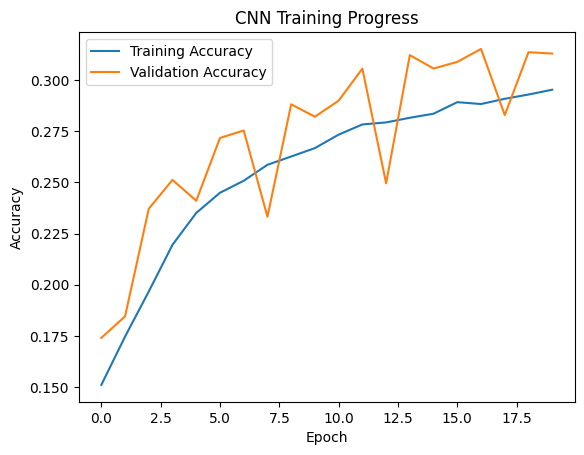

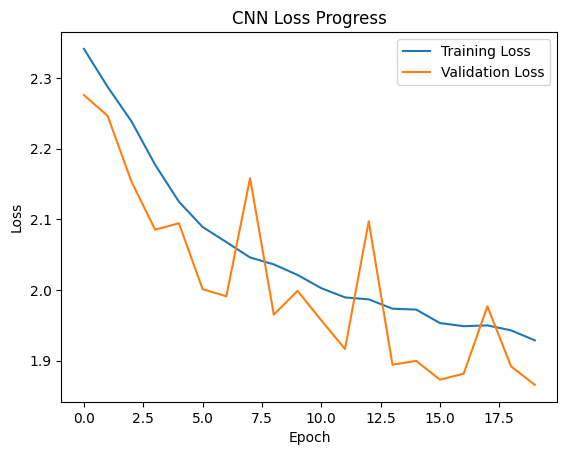

In [ ]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Training Progress")
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN Loss Progress")
plt.show()

**Save model**

In [ ]:
model.save("../models/cnn_tuned_ch2.keras")
print("Model saved successfully!")

Model saved successfully!
